Lets start L1 project named Fitness Watch Data analysis

In [33]:
pip install pandas #installing pandas   

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#installing'


In [34]:
import pandas as pd #importing pandas

In [ ]:
df=pd.read_csv('Apple_Fitness_Data.csv') #reading the given csv file 

In [ ]:
df #displaying the data

,Date,Time,Step Count,Distance,Energy Burned,Flights Climbed,Walking Double Support Percentage,Walking Speed
0,2023-03-21,16:01:23,46,0.02543,14.620,3,0.304,3.060
1,2023-03-21,16:18:37,645,0.40041,14.722,3,0.309,3.852
2,2023-03-21,16:31:38,14,0.00996,14.603,4,0.278,3.996
3,2023-03-21,16:45:37,13,0.00901,14.811,3,0.278,5.040
4,2023-03-21,17:10:30,17,0.00904,15.153,3,0.281,5.184
...,...,...,...,...,...,...,...,...
144,2023-04-01,16:04:23,87,0.05872,13.162,3,0.298,5.364
145,2023-04-01,16:33:18,37,0.02039,4.135,1,0.295,5.400
146,2023-04-01,16:49:49,969,0.65379,31.416,3,0.274,5.292
147,2023-04-01,17:09:06,640,0.42356,13.250,6,0.282,4.860


In [ ]:
df.info() #displaying the information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               149 non-null    object 
 1   Time                               149 non-null    object 
 2   Step Count                         149 non-null    int64  
 3   Distance                           149 non-null    float64
 4   Energy Burned                      149 non-null    float64
 5   Flights Climbed                    149 non-null    int64  
 6   Walking Double Support Percentage  149 non-null    float64
 7   Walking Speed                      149 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 9.4+ KB


In [ ]:
# coverting date time columns to convert to datetime objects
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Extract the hour from the Datetime column
df['Hour'] = df['Datetime'].dt.hour

#Extract the day of the week from the Datetime column (Monday=0, Sunday=6)
df['DayOfWeek'] = df['Datetime'].dt.dayofweek


epsilon = 1e-6
df['EnergyPerStep'] = df['Energy Burned'] / (df['Step Count'] + epsilon)

# Displaying the new columns
print(df[['Hour', 'DayOfWeek', 'EnergyPerStep']].head())

   Hour  DayOfWeek  EnergyPerStep
0    16          1       0.317826
1    16          1       0.022825
2    16          1       1.043071
3    16          1       1.139308
4    17          1       0.891353


# Plot total steps taken per day

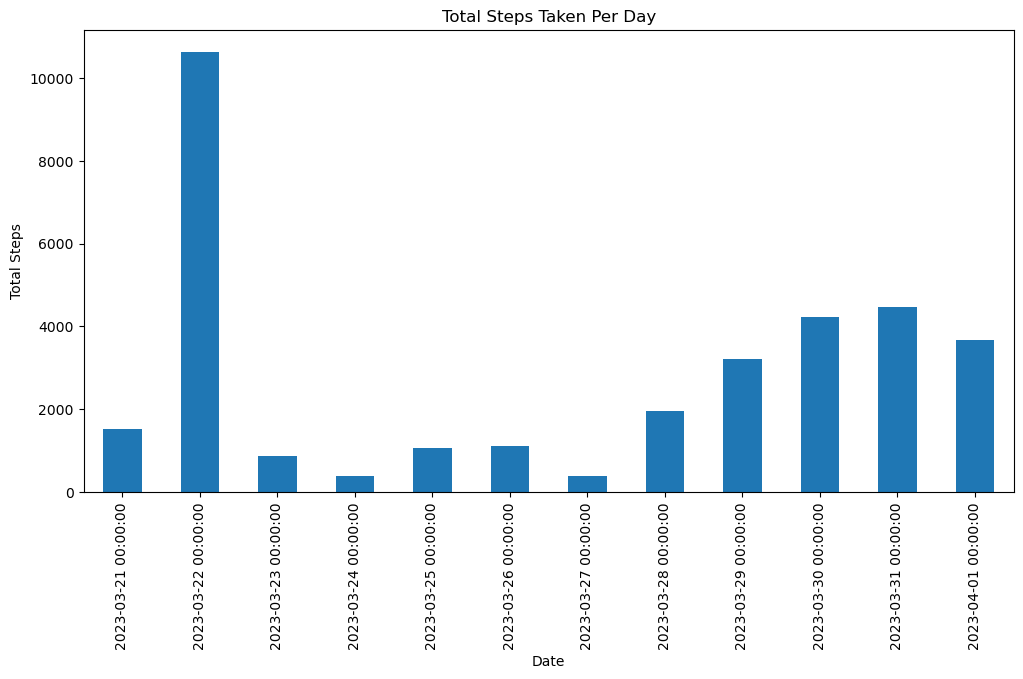

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot total steps taken per day

# Set the Datetime column as the index
df.set_index('Datetime', inplace=True)

plt.figure(figsize=(12, 6))
df['Step Count'].resample('D').sum().plot(kind='bar')
plt.title('Total Steps Taken Per Day')
plt.xlabel('Date')
plt.ylabel('Total Steps')
plt.show()

# Reset the index to avoid affecting other cells
df.reset_index(inplace=True)

plot of energy burned vs distance

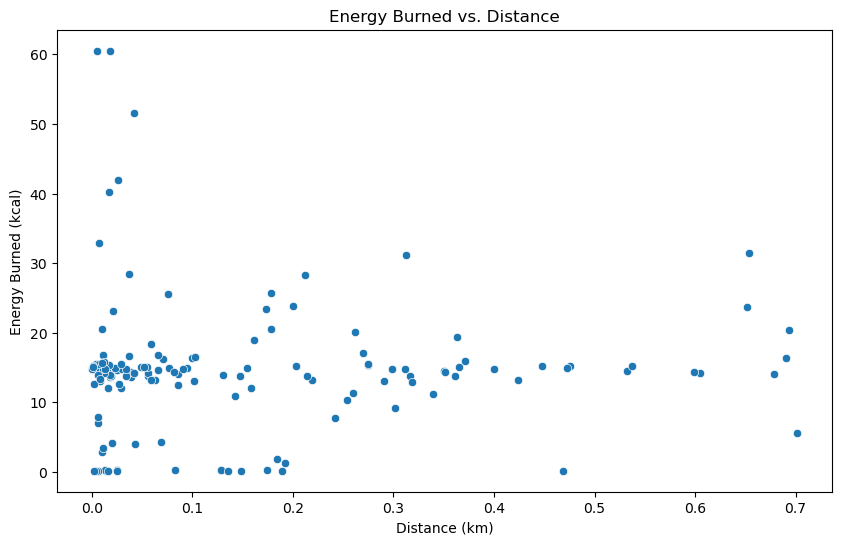

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='Energy Burned', data=df)
plt.title('Energy Burned vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Energy Burned (kcal)')
plt.show()

plot of walking speed vs step count

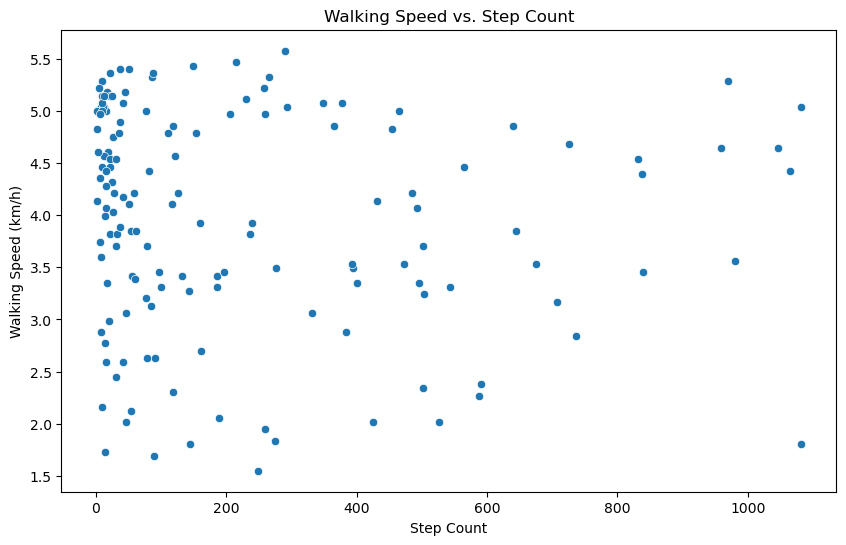

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Step Count', y='Walking Speed', data=df)
plt.title('Walking Speed vs. Step Count')
plt.xlabel('Step Count')
plt.ylabel('Walking Speed (km/h)')
plt.show()

In [ ]:
# define a function to categorize time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# apply the function to the 'Hour' column
df['TimeOfDay'] = df['Hour'].apply(get_time_of_day)

# group by time of day and calculate the average for key metrics
time_of_day_analysis = df.groupby('TimeOfDay')[['Step Count', 'Energy Burned', 'Walking Speed']].mean()
print(time_of_day_analysis)

           Step Count  Energy Burned  Walking Speed
TimeOfDay                                          
Afternoon  260.065217      14.861565       3.703304
Evening    313.774194      13.776306       3.921677
Morning     49.500000      17.394083       4.635000
Night       52.000000      14.265517       4.240552


In [ ]:
# define activity levels based on Step Count quantiles
low_activity_threshold = df['Step Count'].quantile(0.33)
medium_activity_threshold = df['Step Count'].quantile(0.66)

def get_activity_level(steps):
    if steps <= low_activity_threshold:
        return 'Low'
    elif low_activity_threshold < steps <= medium_activity_threshold:
        return 'Medium'
    else:
        return 'High'

df['ActivityLevel'] = df['Step Count'].apply(get_activity_level)

# analyze metrics for each activity level
activity_level_analysis = df.groupby('ActivityLevel')[['Distance', 'Energy Burned', 'Walking Speed']].mean()
print(activity_level_analysis)

               Distance  Energy Burned  Walking Speed
ActivityLevel                                        
High           0.349435      14.801745       3.796235
Low            0.010224      14.787082       4.285469
Medium         0.076008      13.892571       3.846857
